In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Ladda ner data

In [3]:
import kagglehub
 
path = kagglehub.dataset_download(
    "jessemostipak/hotel-booking-demand"
)
 
print(path)

c:\Projekt Data Science\flotation-silica-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\malin\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


## Läsa in data

In [4]:
df = pd.read_csv(os.path.join(path, "hotel_bookings.csv"))

## Första överblick

In [5]:
print(df.shape)
display(df.head())
display(df.info())
display(df.describe().T)
display(df.describe(include="object").T)

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

None

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


C:\Users\malin\AppData\Local\Temp\ipykernel_15728\3204390653.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


### Kommentar till första överblick

119 390 bokningar och 32 kolumner.  
Två saker sticker ut i den numeriska sammanfattningen: adr har ett negativt minimum och ett maximum på 5 400, och adults har minimum 0. Det undersöks i nästa steg.

## Rimlighetskontroller

In [6]:
display(df[df["adr"] < 0])                                       # negativt pris
display(df["adr"].sort_values(ascending=False).head())           # extremt högt värde (~5400)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


48515     5400.0
111403     510.0
15083      508.0
103912     451.5
13142      450.0
Name: adr, dtype: float64

In [28]:
df["total_guests"] = df["adults"] + df["children"].fillna(0) + df["babies"]
no_guests = df[df["total_guests"] == 0]
print(len(no_guests), "bokningar utan gäster")
display(no_guests[["hotel", "is_canceled", "adr", "market_segment", "distribution_channel", "customer_type"]]
        .describe(include="all").T)

180 bokningar utan gäster


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,180,2,City Hotel,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,180.0,NaN,NaN,NaN,0.138889,0.346795,0.0,0.0,0.0,0.0,1.0
adr,180.0,NaN,NaN,NaN,10.4565,31.681635,0.0,0.0,0.0,0.0,200.0
market_segment,180,7,Online TA,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distribution_channel,180,3,TA/TO,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_type,180,4,Transient,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Kommentar rimlighetskontroller

En bokning har negativt pris och en har 5 400 euro per natt, mer än tio gånger det näst högsta.  
**Båda tolkas som registreringsfel och tas bort**   

Bokningar med adr = 0 behålls, eftersom de kan vara gratisvistelser eller kompensationer.

180 bokningar (0,15 %) saknar gäster. Orsaken framgår inte av datan. Troligen är det administrativa poster eller ofullständig registrering. **De tas bort**

## Saknade värden och dubbletter

In [8]:
display(df.isna().sum().sort_values(ascending=False).head(10))
display(df.duplicated().sum())

company                      112593
agent                         16340
country                         488
children                          4
hotel                             0
arrival_date_week_number          0
arrival_date_day_of_month         0
is_canceled                       0
lead_time                         0
stays_in_week_nights              0
dtype: int64

np.int64(31994)

### Kommentar saknade värden och dubbletter

Fyra kolumner har saknade värden:

company (94 %): saknas när bokningen inte görs via ett företag. **Görs om till 0/1, "bokad via företag".**  
agent (14 %): saknas när ingen resebyrå används. **Sätts till 0 och behandlas som en egen kategori.**  
country (488 rader): **sätts till "Unknown". Används inte i modellen eftersom land kan vara läckage.**  
children (4 rader): **sätts till 0.**

31 994 rader (27 %) är identiska. Utan boknings-ID går det inte att avgöra om de är fel eller flera rum i samma bokning. De undersöks närmare längre fram.

## Avbokningar

In [9]:
# Hur stor andel avbokas?

df["is_canceled"].mean().round(2)

np.float64(0.37)

### Kommentar andel avbokningar

37 % av bokningarna avbokas (stadshotellet 41,7 %, semesterhotellet 27,8 %).  
Klasserna är alltså måttligt obalanserade: en modell som aldrig förutsäger avbokning får 63 % rätt men hittar ingen avbokning. Därför används inte accuracy som huvudmått.

<Axes: xlabel='is_canceled', ylabel='lead_time'>

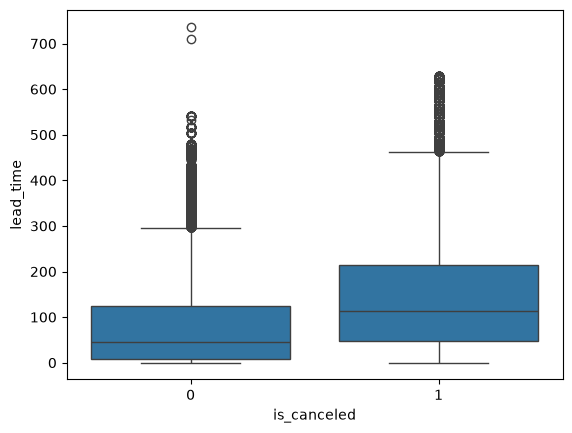

In [10]:
# Påverkar ledtiden om en bokning avbokas? (lead_time = antal dagar mellan bokning och ankomst)

sns.boxplot(data=df, x="is_canceled", y="lead_time")

### Kommentar ledtid och avbokningar

Avbokade bokningar har klart längre ledtid, med en median kring 115 dagar mot cirka 45 för genomförda.  
Spridningen är stor och fördelningarna överlappar, så ledtid ensam räcker inte för att skilja grupperna åt.  
Det är ändå den tydligaste enskilda variabeln, och därför används den som baseline.

<Axes: title={'center': 'Genomsnittligt pris per natt (adr) per ankomstmånad'}, xlabel='arrival_date_month'>

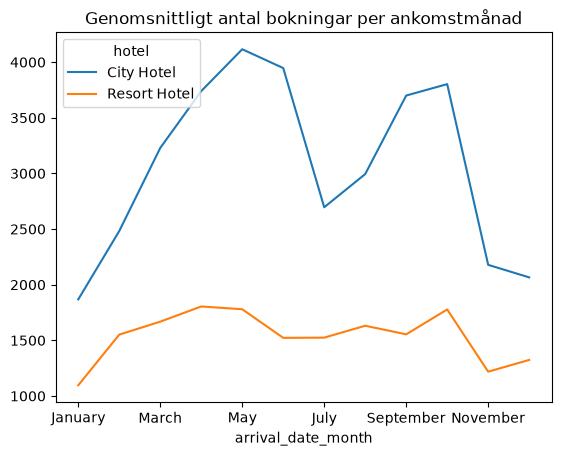

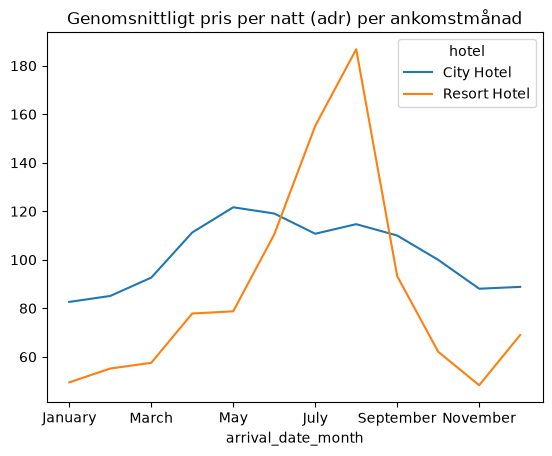

In [29]:
# Säsongsmönster för avbokningar

month_order = ["January","February","March","April","May","June","July",
               "August","September","October","November","December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], month_order, ordered=True)

per_year = df.groupby(["arrival_date_year", "arrival_date_month", "hotel"], observed=True).size()
per_year.groupby(["arrival_date_month", "hotel"], observed=True).mean().unstack() \
      .plot(title="Genomsnittligt antal bokningar per ankomstmånad")

df.groupby(["arrival_date_month", "hotel"], observed=True)["adr"].mean().unstack() \
  .plot(title="Genomsnittligt pris per natt (adr) per ankomstmånad")

### Kommentar säsongsmönster avbokningar

Båda hotellen har flest ankomster under vår och sommar och färre under vintern.  
Priset skiljer sig mer: semesterhotellet har en tydlig sommartopp och är billigast på vintern, medan stadshotellets pris är jämnare över året med högst nivå under våren och försommaren.  Ankomstmånad kan därför vara relevant för modellen, och mönstret skiljer sig mellan hotellen.

In [12]:
# Vilka faktorer påverkar om en bokning avbokas? (is_canceled = 1)

for col in ["deposit_type", "market_segment", "customer_type", "distribution_channel"]:
    print(df.groupby(col)["is_canceled"].agg(["mean", "count"]).sort_values("mean"), "\n")

                  mean   count
deposit_type                  
Refundable    0.222222     162
No Deposit    0.283770  104641
Non Refund    0.993624   14587 

                    mean  count
market_segment                 
Complementary   0.130552    743
Direct          0.153419  12606
Corporate       0.187347   5295
Aviation        0.219409    237
Offline TA/TO   0.343160  24219
Online TA       0.367211  56477
Groups          0.610620  19811
Undefined       1.000000      2 

                     mean  count
customer_type                   
Group            0.102253    577
Transient-Party  0.254299  25124
Contract         0.309617   4076
Transient        0.407463  89613 

                          mean  count
distribution_channel                 
Direct                0.174599  14645
GDS                   0.191710    193
Corporate             0.220758   6677
TA/TO                 0.410259  97870
Undefined             0.800000      5 



### Kommentar faktorer som påverkar avbokningar

Avbokningsgraden skiljer sig tydligt mellan kategorier. Ej återbetalningsbara bokningar avbokas i 99,4 % av fallen, vilket undersöks längre ned och visar sig vara gruppblock från resebyråer.  
Bland marknadssegmenten avbokar Groups (61 %) och onlinebyråer (37 %) mest, medan direktbokningar (15 %) och företag (19 %) avbokar minst.  
Samma mönster syns i distributionskanal, där bokningar via resebyrå avbokas oftare. Kundtypen Transient har högst andel (41 %).  
Kategorierna "Undefined" har bara några få bokningar och kan slås ihop eller **tas bort**.

<Axes: >

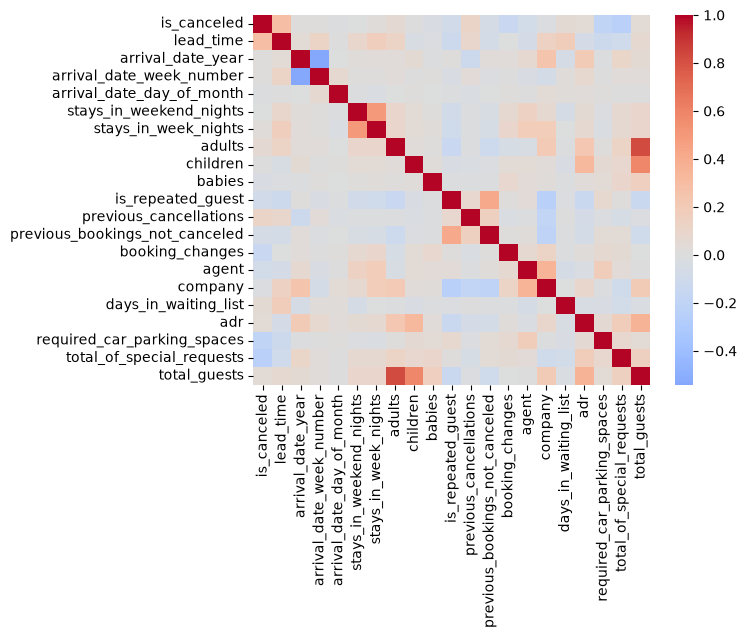

In [14]:
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm", center=0)

### Kommentar heatmap

De flesta variabler har svag linjär korrelation med is_canceled.  
Starkast är ledtid (positiv) samt antal specialönskemål och parkeringsplatser (negativa).  
Specialönskemål och parkering kan dock registreras eller ändras efter bokningen, eller först vid ankomst, och används därför inte i huvudmodellen.

## Skapa tidsvariabler

I datasetet finns inte bokningsdatum men det kan skapas uutifrån dessa variabler:

arrival_date_day_of_month -> Day of the month of the arrival date  
arrival_date_month -> Month of arrival date with 12 categories: “January” to “December”  
arrival_date_year -> Year of arrival date  
lead_time -> Number of days that elapsed between the entering date of the booking into the PMS and the arrival date  

In [15]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-"
    + df["arrival_date_month"].astype(str) + "-"
    + df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
)
df["booking_date"] = df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D")
df["outcome_date"] = pd.to_datetime(df["reservation_status_date"])

# Rimlighetskontroll: utfallet ska inte ligga före bokningen
print((df["outcome_date"] < df["booking_date"]).sum())

0


### Kommentar tidsvariabler

outcome_date bygger på reservation_status_date, som anger när bokningens status senast ändrades. Vad datumet betyder beror på utfallet:

avbokade bokningar: datumet för avbokningen  
genomförda bokningar: utcheckningsdatumet  
no-show: ankomstdatumet  

Rimlighetskontrollen visar att inget utfall ligger före bokningsdatumet.

Variabeln används bara för att avgöra när utfallet blev känt, så att träningsdata vid varje prognostidpunkt bara innehåller bokningar vars utfall redan var känt. Den används inte som variabel i modellen, eftersom den avslöjar utfallet.

**Att undersöka vidare:** Eftersom avbokningar blir kända tidigare än genomförda bokningar kan träningsdata få för hög avbokningsgrad. Ett alternativ är att i stället filtrera på avresedatum (ankomstdatum + antal nätter), då utfallet är känt för alla bokningar. Vilket av alternativen som ska användas i tidsuppdelningen avgörs senare.

## Tidsperiod och bokningar över tid

In [ ]:
# Datumintervall för bokningar, ankomster och utfall

df[["booking_date", "arrival_date", "outcome_date"]].agg(["min", "max"])

,booking_date,arrival_date,outcome_date
min,2013-06-24,2015-07-01,2014-10-17
max,2017-08-31,2017-08-31,2017-09-14


### Kommentar tidsperioder

Datasetet omfattar ankomster mellan 1 juli 2015 och 31 augusti 2017. Bokningsdatumen börjar tidigare, i juni 2013, eftersom vissa bokningar görs upp till två år före ankomst. Utfallsdatumen sträcker sig till september 2017, eftersom gäster som anlände i slutet av augusti checkade ut några dagar senare.

<Axes: xlabel='booking_date'>

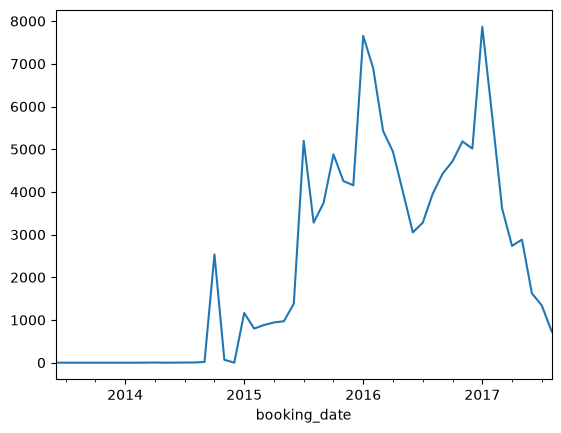

In [ ]:
# Plotta antal bokningar per månad (MS = Month Start)

df.set_index("booking_date").resample("MS").size().plot()

### Kommentar tidsfördelning

Antalet bokningar per bokningsmånad visar att datan är ofullständig i båda ändar:

- **Början:** Före juli 2015 finns bara bokningar med ankomst efter juli 2015, alltså bokningar med lång ledtid. Antalet är därför lågt fram till sommaren 2015.
- **Slutet:** Bokningar från 2017 finns bara med om ankomsten skedde senast i augusti 2017. Bokningar med lång ledtid saknas, och kurvan faller brant under 2017.
- **Toppen i oktober 2014:** En avvikande topp med cirka 2 500 bokningar. Den undersöks närmare nedan.

Topparna i januari 2016 och januari 2017 är säsongsmönster: många bokar sommarens resor tidigt på året.

Bokningarna är mest kompletta ungefär från mitten av 2015 till slutet av 2016. Det påverkar var prognostidpunkten och testperioden kan läggas: testbokningarna måste ha tillräckligt med tid fram till datans slut för att de flesta ankomster ska finnas med.

In [ ]:
# Undersökning av peak-perioden hösten 2014 (September + Oktober)

peak_2014 = df[(df.booking_date >= "2014-09-01") & (df.booking_date < "2014-11-01")]
print(peak_2014["hotel"].value_counts())
print("Andel avbokade:", round(peak_2014["is_canceled"].mean(), 3))
print(peak_2014["deposit_type"].value_counts())
print(peak_2014["agent"].value_counts().head())
print("Andel dubbletter:", round(peak_2014.duplicated().mean(), 3))

hotel
City Hotel      2509
Resort Hotel      44
Name: count, dtype: int64
Andel avbokade: 0.919
deposit_type
Non Refund    1562
No Deposit     991
Name: count, dtype: int64
agent
1.0     2065
6.0      350
5.0       74
21.0      16
40.0       9
Name: count, dtype: int64
Andel dubbletter: 0.918


### Kommentar topp i september-oktober 2014

Bokningarna som gjordes i september–oktober 2014 skiljer sig tydligt från resten av datan:

- Nästan alla (2 509 av 2 553) gäller stadshotellet.
- 92 % avbokades, jämfört med 37 % i hela datan.
- 61 % är ej återbetalningsbara, jämfört med 12 % i hela datan.
- Cirka 80 % är bokade via samma resebyrå (agent 1).
- 92 % är identiska rader.

Mönstret tyder på att det inte är enskilda gästbokningar utan stora block av rum som en resebyrå reserverade i förväg och sedan avbokade.  
Nedan undersöks när avbokningarna skedde och om samma mönster finns i resten av datan.

In [ ]:
# Undersökning av avbokningar under peak-perioden

canc_peak_2014 = peak_2014[peak_2014.is_canceled == 1]
print(canc_peak_2014["outcome_date"].value_counts().head())   # avbokades de samma dag?
print(peak_2014["lead_time"].describe())
print(peak_2014["country"].value_counts().head())

# Hur mycket av hela datan följer samma mönster?
grupp = df[(df.agent == 1) & (df.deposit_type == "Non Refund")]
print(len(grupp), grupp["is_canceled"].mean(), grupp.duplicated().mean())

outcome_date
2015-01-01    761
2015-07-06    520
2015-07-02    419
2014-10-17    180
2015-07-23     93
Name: count, dtype: int64
count    2553.000000
mean      312.970623
std        34.814301
min       257.000000
25%       283.000000
50%       311.000000
75%       339.000000
max       414.000000
Name: lead_time, dtype: float64
country
PRT    2535
GBR      11
IRL       2
ESP       2
SWE       1
Name: count, dtype: int64
4072 1.0 0.9290275049115914


### Kommentar avbokningsmönster

Fler kontroller stärker bilden av att det rör sig om gruppblock:

- **Avbokningarna skedde i några få stora omgångar.** Över 1 800 avbokningar är samlade på fyra datum, med flest (761) den 1 januari 2015. Så många avbokningar samma dag tyder på att hela block släpptes på en gång. Att så många ligger på nyårsdagen kan också betyda att datumet är ett standardvärde i systemet snarare än det faktiska avbokningsdatumet.  
- **Ledtiden är nästan densamma för alla.** Alla bokningar gjordes 257–414 dagar före ankomst, det vill säga ungefär samtidigt för ankomster spridda över en längre period.  
- **Nästan alla är registrerade som portugisiska (99 %).** Land är här troligen ett standardvärde, till exempel resebyråns eller hotellets land, och inte gästens nationalitet. Det kan förklara en del av den höga avbokningsgraden för PRT.  
- **Mönstret finns i hela datan.** Kombinationen agent 1 och ej återbetalningsbar förekommer i 4 072 bokningar, alla avbokade och 93 % identiska rader.

Nästa steg är att se om fler resebyråer har samma mönster.

In [38]:
# Jämförelse av de tio vanligaste byråerna bland Non Refund-bokningar:
# deras ej återbetalningsbara bokningar jämfört med deras övriga bokningar

nr = df[df.deposit_type == "Non Refund"]
topp = nr["agent"].value_counts().head(10).index
topp_df = df[df.agent.isin(topp)].copy()
topp_df["typ"] = np.where(topp_df.deposit_type == "Non Refund", "Non Refund", "Övriga")

tabell = (topp_df.groupby(["agent", "typ"])["is_canceled"]
          .agg(antal="size", andel_avbokade="mean")
          .unstack("typ")
          .round(3))
tabell.columns = ["Antal Non Refund", "Antal övriga",
                  "Andel avbokade Non Refund", "Andel avbokade övriga"]
tabell.index = tabell.index.astype(int)
tabell.index.name = "Resebyrå (agent)"
display(tabell.sort_values("Antal Non Refund", ascending=False))

print("Antal Non Refund totalt:", len(nr))
print("Andel dubbletter bland Non Refund:", round(nr.duplicated().mean(), 3))
print("Andel PRT bland Non Refund:", round((nr.country == "PRT").mean(), 3))

,Antal Non Refund,Antal övriga,Andel avbokade Non Refund,Andel avbokade övriga
Resebyrå (agent),,,,
1,4072,3119,1.0,0.387
19,719,342,1.0,0.178
6,642,2648,1.0,0.145
37,627,603,1.0,0.149
3,623,713,1.0,0.208
29,500,183,1.0,0.251
21,375,500,1.0,0.262
229,340,446,1.0,0.323
20,256,284,1.0,0.363


Antal Non Refund totalt: 14587
Andel dubbletter bland Non Refund: 0.929
Andel PRT bland Non Refund: 0.972


### Kommentar ej återbetalningsbara bokningar

Samma mönster som för agent 1 gäller för ej återbetalningsbara bokningar i allmänhet:

- **14 587 bokningar (12 % av datan) är ej återbetalningsbara.** Eftersom nästan alla avbokas utgör de ungefär en tredjedel av alla avbokningar.
- **De tio vanligaste resebyråerna har alla 100 % avbokningar för sina ej återbetalningsbara bokningar.** Mönstret gäller alltså många byråer och inte bara agent 1.
- **Samma byråer har 15–51 % avbokningar för sina övriga bokningar**, vilket ligger nära eller något över datans genomsnitt. Det är alltså depositionstypen och inte byråerna i sig som står för mönstret.
- **93 % är identiska rader**, vilket motsvarar ungefär 13 500 av datans cirka 32 000 dubbletter.
- **97 % är registrerade som portugisiska.**

Ej återbetalningsbar deposition verkar i praktiken markera gruppblock eller förhandsreservationer från resebyråer, inte enskilda gäster som betalat i förväg och ändå avbokat. Det förklarar varför ej återbetalningsbara bokningar avbokas i 99,4 % av fallen, och det kan förklara en stor del av dubbletterna och den höga avbokningsgraden för portugisiska gäster. Nedan undersöks hur avbokningsgraden ser ut utan dessa bokningar.

In [41]:
ovr = df[df.deposit_type != "Non Refund"]
print("Avbokningsgrad totalt:", df.is_canceled.mean().round(3), "utan Non Refund:", ovr.is_canceled.mean().round(3))
print(ovr.groupby("hotel")["is_canceled"].mean().round(3))
print("PRT:", ovr[ovr.country == "PRT"].is_canceled.mean().round(3),
      "övriga:", ovr[ovr.country != "PRT"].is_canceled.mean().round(3))
print("Dubbletter kvar:", ovr.duplicated().sum())

Avbokningsgrad totalt: 0.37 utan Non Refund: 0.284
hotel
City Hotel      0.305
Resort Hotel    0.247
Name: is_canceled, dtype: float64
PRT: 0.389 övriga: 0.232
Dubbletter kvar: 18445


### Kommentar avbokningar utan ej återbetalningsbara bokningar

När de ej återbetalningsbara bokningarna tas bort förändras flera av de tidigare fynden:

| | Alla bokningar | Utan Non Refund |
|---|---|---|
| Avbokningsgrad totalt | 37,0 % | 28,4 % |
| Stadshotellet | 41,7 % | 30,5 % |
| Semesterhotellet | 27,8 % | 24,7 % |
| Portugal (PRT) | 57 % | 38,9 % |
| Övriga länder | ca 20 % | 23,2 % |
| Identiska rader | 31 994 | 18 445 |

- **Skillnaden mellan hotellen krymper** från cirka 14 till cirka 6 procentenheter. Stadshotellets höga avbokningsgrad berodde till stor del på gruppblocken.  
- **Skillnaden mellan PRT och övriga länder halveras men finns kvar.** Resten kan förklaras av att nationaliteten ofta registreras först vid incheckningen (Antonio m.fl., 2019). Land behandlas därför fortfarande som läckage.  
- **Drygt 40 % av dubbletterna försvinner.** De som återstår undersöks nedan.  
- **Majoritetsklassen blir 71,6 %**, så obalansen ökar något.  

Beslut: huvudanalysen omfattar bokningar som inte är ej återbetalningsbara, eftersom de beter sig som gruppblock och inte som enskilda bokningar.  
Om tid finns körs modellerna även med dessa bokningar, för att visa hur mycket de påverkar resultatet (eller ta bort med motivering).

In [22]:
dup = ovr.duplicated(keep=False)
print("Andel dubbletter:", dup.mean())
print("Avbokningsgrad dubbletter:", ovr[dup].is_canceled.mean(),
      "övriga:", ovr[~dup].is_canceled.mean())
print(ovr[dup]["market_segment"].value_counts(normalize=True).head())


Andel dubbletter: 0.2466437029474347
Avbokningsgrad dubbletter: 0.3551007775929436 övriga: 0.2602908022392786
market_segment
Online TA        0.318117
Groups           0.297342
Offline TA/TO    0.280939
Direct           0.053929
Corporate        0.046037
Name: proportion, dtype: float64


### Kommentar dubbletter som återstår

Bland bokningarna utan Non Refund har 24,7 % minst en identisk rad (både originalet och kopiorna räknas). De skiljer sig från övriga bokningar:

- **Högre avbokningsgrad:** 35,5 % mot 26,0 % för övriga bokningar.
- **Mest via grupper och resebyråer:** Online TA 32 %, Groups 30 % och Offline TA/TO 28 %. Direktbokningar och företagsbokningar står bara för cirka 10 %.

Dubbletterna ser därför till största delen ut som riktiga bokningar och inte som fel. Grupper och researrangörer bokar ofta flera likadana rum, och eftersom datasetet saknar boknings-ID blir de identiska rader. Bland onlinebokningarna kan identiska rader också uppstå när olika gäster bokar samma rumstyp, datum och pris. Den högre avbokningsgraden stämmer med att ett sällskap som avbokar tar bort alla sina rum samtidigt.

**Beslut:** Dubbletterna behålls, eftersom de troligen är verkliga bokningar och hotellet förlorar ett rum per avbokad rad. Identiska rader har samma bokningsdatum och hamnar därför alltid i samma delmängd vid tidsuppdelningen, så de kan inte förekomma både i tränings- och testdata. En nackdel är att gruppbeslut väger tyngre än enskilda beslut, eftersom de räknas en gång per rum.